## Introduction 

In [10]:
# read() read all the file as string, and splitlines() splits by new line '/n'
names = open('names.txt', 'r').read().splitlines() 

In [13]:
names[:5], len(names)

(['emma', 'olivia', 'ava', 'isabella', 'sophia'], 32033)

In [14]:
min(names, key=len) # shortest name

'an'

In [16]:
max(names, key=len) # largest name

'muhammadibrahim'

### Character Level Language Model

<p style="font-size:18px;">
    <b>Intuition:</b> is to predict the next character in a sequence of characters.
    Take for example the name <code>Omar</code>. What can we extract from this name?
</p>

<ul style="font-size:18px;">
    <li>
        <b>O</b> — a character that most likely begins a name.
    </li>
    <li>
        <b>m</b> — a character that most likely follows <b>o</b> in a name.
    </li>
    <li>
        <b>a</b> — a character that most likely follows <b>m</b> in a given name.
    </li>
    <li>
        <b>r</b> — a character that most likely follows <b>a</b>, and also indicates the name ends
        (<span style="color: rgb(255, 148, 148);">
            i.e., there are no more characters and generation should stop
        </span>).
    </li>
</ul>

<p style="font-size:18px;">
    So it is a statistical model, based on frequency of characters. 
</p>


In [48]:
for w in names[:1]: # sliding window of size two charactes
    for w1, w2 in zip(w, w[1:]): 
        print(w1, w2)

e m
m m
m a


In [52]:
for w in names[:1]:
    chs = ['<S>'] + list(w) + ['<W>'] # ['<S>', 'e', 'm', 'm', 'a', '<E>']
    for w1, w2 in zip(chs, chs[1:]): 
        print(w1, w2)

<S> e
e m
m m
m a
a <W>


In [53]:
for w in names[:3]:
    chs = ['<S>'] + list(w) + ['<W>'] # ['<S>', 'e', 'm', 'm', 'a', '<E>']
    for w1, w2 in zip(chs, chs[1:]): 
        print(w1, w2)

<S> e
e m
m m
m a
a <W>
<S> o
o l
l i
i v
v i
i a
a <W>
<S> a
a v
v a
a <W>


<p style="font-size:18px;">
we then create a dictionary that counts each one of these Bigram, like what is the most likely character to follow <br>    <code> '< S >' </code>, that will be the most character that start a word, what is the most character that likely to follow, 
        a an arbitrary character m, etc. 
</p>




In [58]:
b = {}
for w in names[:3]:
    chs = ['<S>'] + list(w) + ['<W>'] 
    for w1, w2 in zip(chs, chs[1:]): 
        bigram = (w1, w2) # create a tuple
        
        b[bigram] = b.get(bigram, 0) + 1 
        # b.get() will check if bigram exist if not, return 0, instead of an error. And then add 1. 
    

In [57]:
b # ('a', '<W>'): 3 were the most likely pair of these 3 words, the 3 words ended with 'a'. 

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<W>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [59]:
b = {}
for w in names:
    chs = ['<S>'] + list(w) + ['<W>'] 
    for w1, w2 in zip(chs, chs[1:]): 
        bigram = (w1, w2) 
        b[bigram] = b.get(bigram, 0) + 1 

In [74]:
max(b, key=b.get)

('n', '<W>')

In [75]:
b.get(('n', '<W>')) 

6763

<p style ="font-size:18ps;"> 6763 words ended with a character <b> n </b> </p>

In [76]:
min(b, key=b.get)

('q', 'r')

In [77]:
b.get(('n', 'r'))

44

<p style ="font-size:18ps;"> least frequent pair is<b> n </b> followed by <b> r </p>

In [153]:
sorted(b.items(), key=lambda x: x[1], reverse=True)[:10]

[(('n', '<W>'), 6763),
 (('a', '<W>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<W>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

## Create Bigram in a Tensor for efficiency

In [82]:
import torch

In [86]:
N = torch.zeros(28, 28, dtype=torch.int32) # all english alphabet plus <S> and <E>
# co-occurrence matrix of all alphabets with each other

In [93]:
alpha = sorted(list(set(''.join(names)))) 
# join all words into a single list, remove duplicated, sort it, we get all the alphabet ordered

In [100]:
# Then map each character into a number like a dict
# String into a index stoi
stoi = {s:i for i, s in enumerate(alpha)}
stoi['a']

0

In [104]:
# Then add two special characters 
stoi['<S>'] = 26
stoi['<E>'] = 27


In [108]:
# Use our look up table of each character, to index the tensor and count each letter
for w in names: 
    chs = ['<S>'] + list(w) + ['<E>']
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        N[index1, index2] += 1

In [112]:
import matplotlib.pyplot as plt
%matplotlib inline

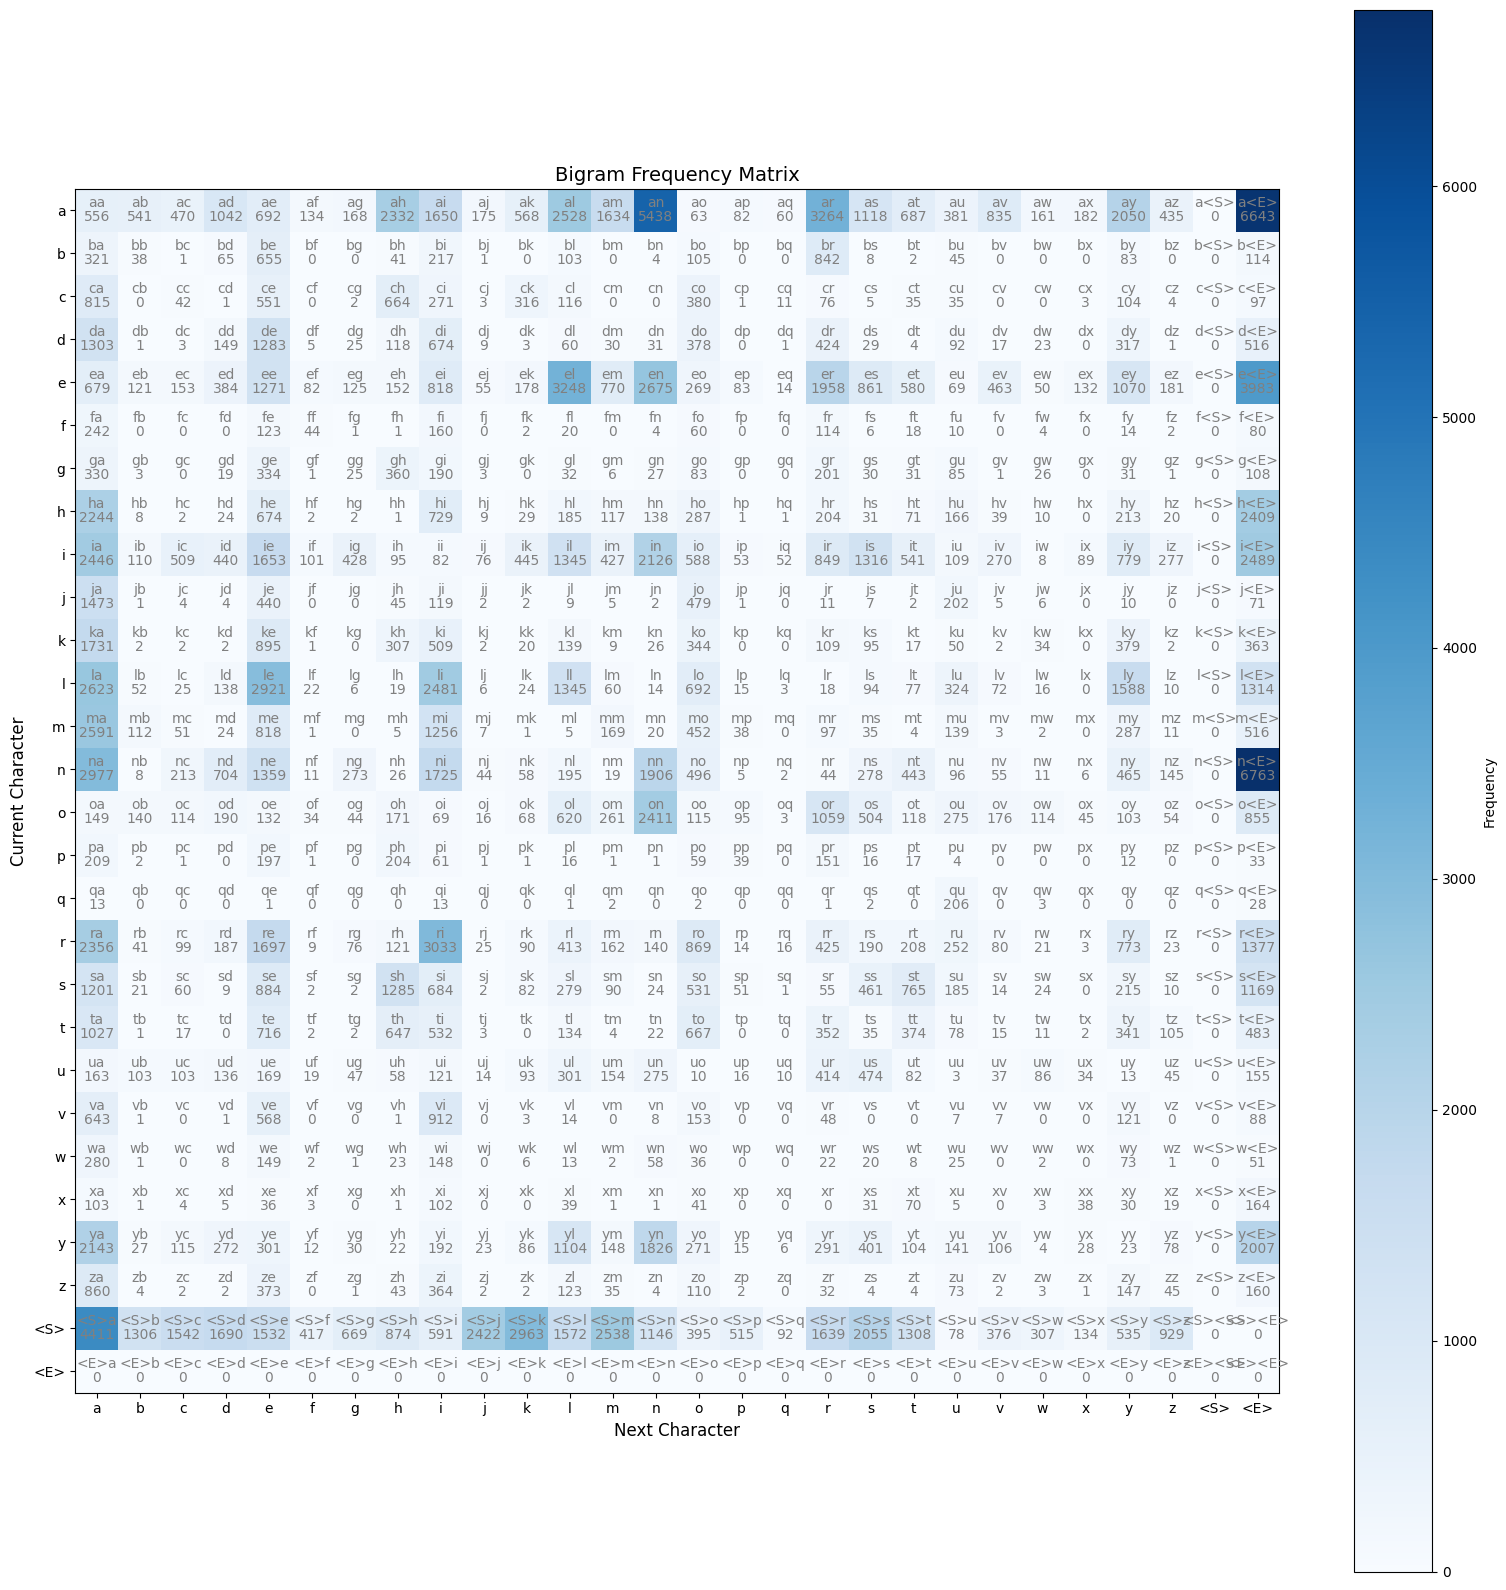

In [132]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

itos = {i: s for s, i in stoi.items()} # reverse index to string

for i in range(28):
    for j in range(28):
        bigram = itos[i] + itos[j] # two characters aa, ab, ac, etc
        
        count = N[i, j].item()  # .item() to extract number from tensor
        
        plt.text(j, i, bigram, ha="center", va="bottom", color='gray')
        plt.text(j, i, count, ha="center", va="top", color='gray')
        

plt.xticks(range(28), [itos[i] for i in range(28)], fontsize=10)
plt.yticks(range(28), [itos[i] for i in range(28)], fontsize=10)
plt.xlabel('Next Character', fontsize=12)
plt.ylabel('Current Character', fontsize=12)
plt.title('Bigram Frequency Matrix', fontsize=14)
plt.colorbar(label='Frequency')
plt.tight_layout()
plt.show()

### Interpreting the Matrix 

<p style="font-size:18px;"> As you can see the Last Row, <code>< E ></code> is starting zero times, because it is a special token that defines a end of a name. So it is starting zero times.<br> <br>
    Also the column before the ending <code> < S > </code> is also ending zero times. Because that is a special token to denote a the starting letter of a name. <br> </p>

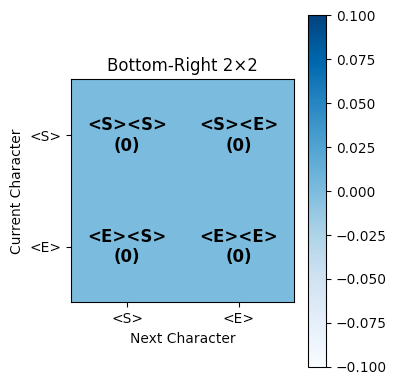

<p style="font-size:18px;"> As you can see the these special tokens never follow each other, so we have a wasted space, so we this by removing one special character, and leaving only one. </p>

### Removing one special token

In [186]:
N = torch.zeros((27, 27), dtype=torch.int)

In [187]:
stoi = {s:i+1 for i, s in enumerate(alpha)} # start from one
stoi['.'] = 0 # Special token at zeroth position. 
stoi['.']

0

In [188]:
for w in names: 
    chs = ['.'] + list(w) + ['.'] # '.'. at the start '.' at the end of name
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        N[index1, index2] += 1

In [ ]:
itos = {i: s for s, i in stoi.items()} 
itos[0], itos[1]

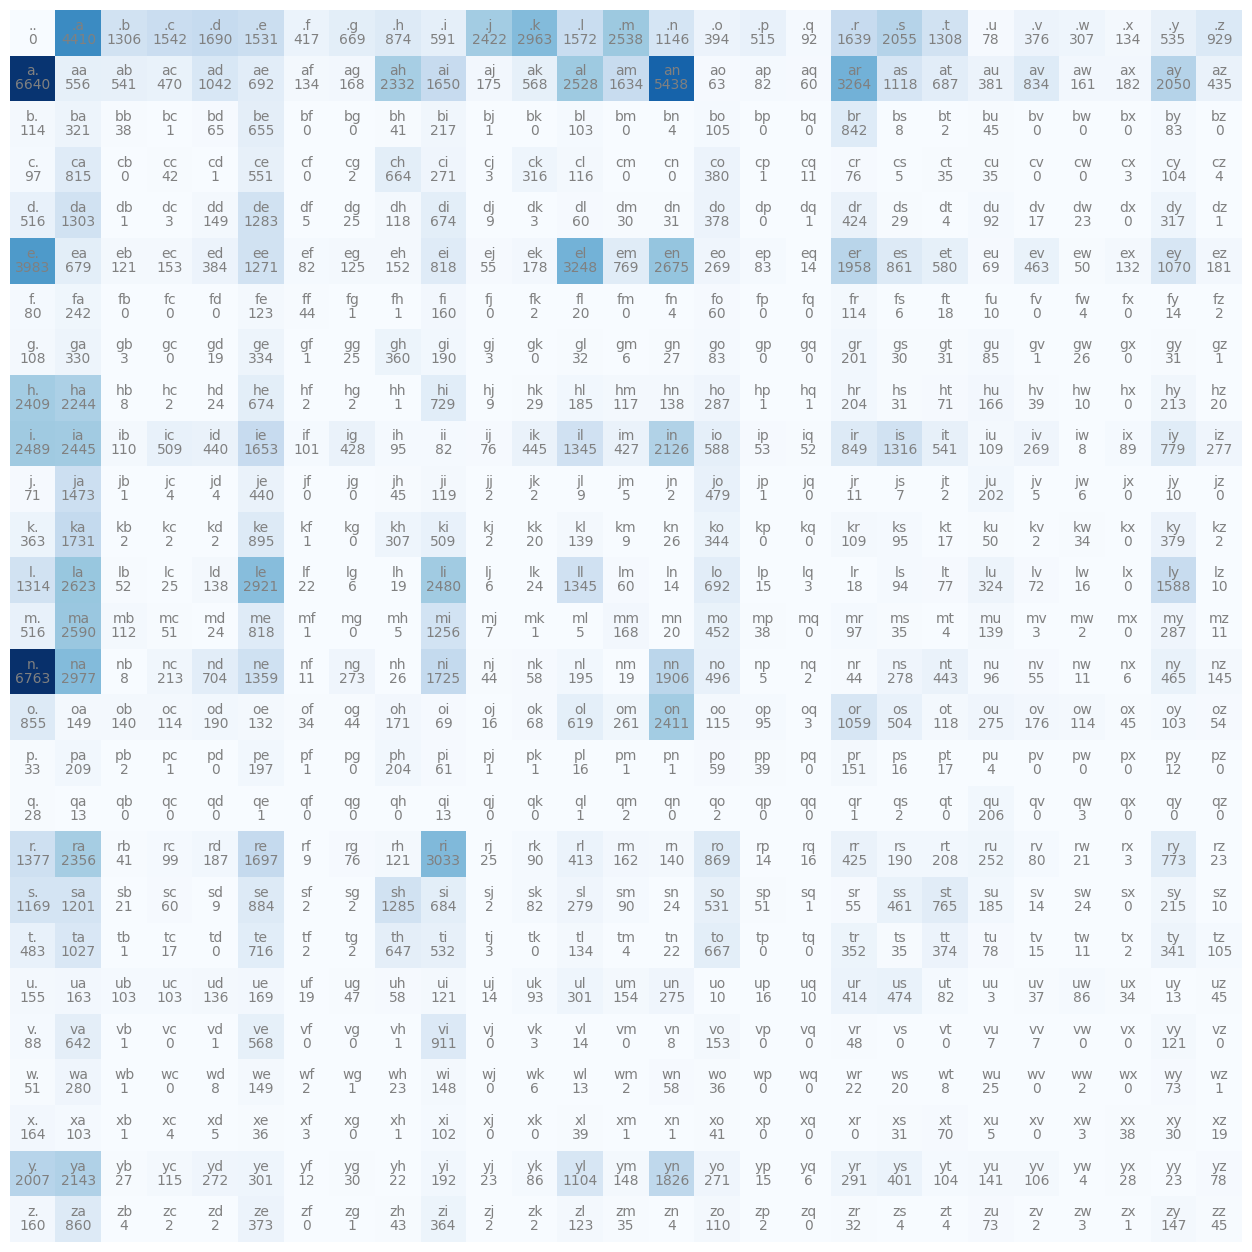

In [189]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        bigram = itos[i] + itos[j] # two characters aa, ab, ac, etc
        
        count = N[i, j].item()  # .item() to extract number from tensor
        
        plt.text(j, i, bigram, ha="center", va="bottom", color='gray')
        plt.text(j, i, count, ha="center", va="top", color='gray')
        
plt.axis('off');

<p style="font-size:18px;"> Now!! '..' appears zero time, because they never follow each other and we have less wasted rows and columns</p>

## Multinomial Distribution

<p style="font-size:18px;"> We are going to use Multinomial Dist. I will explain it briefly here, but you could watch this video <a href=https://www.youtube.com/watch?v=Dkc_hcVWDpA>here</a> To get a better grasp.<br> <br> 
The whole idea, given a for a number of categories, and I want to sample from it, what numbers will be drawn back. Like I have a bag that contain 20 red balls, 50 green balls, 30 blue balls. And I have taken for example 10 random balls with replacement i.e I draw the ball and put it back again, what is the probability to get 3 red balls out of the ten or 1 red, 4 green, 5 blue, etc. Of course the underlying probability of the all possibilities should sum to one. 20% + 50% + 30% = 1, to get the probability of each one, we divide the number of each category balls over the sum. $$red ball = \dfrac{20}{20+50+30} = 20\%$$   </p

In [195]:
'''
we use manual seed, so we get the same results, i.e to get a reproducable resutls
so that torch.rand() will genreate the  same random numbers for this number of manual seed
'''
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p 

tensor([0.7081, 0.3542, 0.1054])

<b>We have three random numbers, let's sum and divide each one by the total to get a probability distribution<b>

In [196]:
p = p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

<b>The probability of getting the first is one is 60% and second is 30% and third is almost 10%, in other words
    the probability of getting the first number is 6 times more likely than the third, and two times more likely than the second<b>

In [204]:
samples= torch.multinomial(p, num_samples=15, replacement=True, generator=g)
samples

tensor([1, 1, 0, 1, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0])

<b><span style="font-weight:700; color: rgb(255, 148, 148);">
   As you can see we get 0 more times than (1 and 2 individually) and 2 is more times than zero, as the number of samples increase it should approach 60%, 30%,10% based on the Law of Large Numbers. 
</span>
<b>

In [207]:
# count occurrences
counts = torch.bincount(samples)

# normalize by total
proportions = counts / samples.numel()

counts, proportions

(tensor([8, 6, 1]), tensor([0.5333, 0.4000, 0.0667]))

<b> As you can 0 is about 50%, and 1 is 40% and 2 is 6% </b>

In [212]:
samples= torch.multinomial(p, num_samples=500, replacement=True, generator=g)
counts = torch.bincount(samples)
proportions = counts / samples.numel()

counts, proportions

(tensor([309, 149,  42]), tensor([0.6180, 0.2980, 0.0840]))

<b> Get more closer to the real expected numbers of distribution </b>

### Now applying Multinomial  Distribution to the N matrix of bigrams

In [214]:
N.shape

torch.Size([27, 27])

<p style="font-size:18px;"> We have 27,27 Matrix, so we have for each letter and special token, how many occurrences happened followed by each letter, based on our text data we have. Rows contain letters and special token and columns for each contain the number of occurrences with that row. 
</p>

In [217]:
itos[0],N[0]

('.',
 tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929], dtype=torch.int32))

That means '.' occurred zero times after '.'
- 'a' occurred 4410 times after '.'
- 'b' occurred 1306 after '.'
etc

In [234]:
p = N[0].float() # we make it float since we are going to divide
p = p /p.sum() # and we each entry over sum to get a probability
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

These probabilities should sum to one

In [235]:
p.sum()

tensor(1.)

In [288]:
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g)
ix.item() # item() extract number from tensor

13

In [289]:
itos[ix.item()]

'm'

And it makes sense, if you look at the occurrences of 'm' after '.' it happened 2538, so it makes sense to appear in a sample, since it has a high probability to be chosen. 

Now we make a loop of drawn samples to get a name, like after 'm', we see which character is more likely to be 
be chosen after m, etc, until we hit a .

In [304]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20): 
    out = []
    ix = 0 
    while True: 
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0: # we sampled '.' the name has ended
            break

    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


<p style="font-size:18px;"> By the way this names, while they appear to be bad, they are actually better, if you compare them, to untrained mode, like that have uniform of distribution i.e not trained on any dataset, every character chance has the same probability as the other</p>

In [307]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20): 
    out = []
    ix = 0 
    while True: 
        p = torch.ones(27) / 27.0
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0: # we sampled '.' the name has ended
            break

    print(''.join(out))

cexzm.
zoglkurkicqzktyhwmvmzimjttainrlkfukzkktda.
sfcxvpubjtbhrmgotzx.
iczixqctvujkwptedogkkjemkmmsidguenkbvgynywftbspmhwcivgbvtahlvsu.
dsdxxblnwglhpyiw.
igwnjwrpfdwipkwzkm.
desu.
firmt.
gbiksjbquabsvoth.
kuysxqevhcmrbxmcwyhrrjenvxmvpfkmwmghfvjzxobomysox.
gbptjapxweegpfwhccfyzfvksiiqmvwbhmiwqmdgzqsamjhgamcxwmmk.
iswcxfmbalcslhy.
fpycvasvz.
bqzazeunschck.
wnkojuoxyvtvfiwksddugnkul.
fuwfcgjz.
abl.
j.
nuuutstofgqzubbo.
rdubpknhmd.


<b><span style="font-weight:700; color: rgb(230, 0, 0);">
    Comparing to the bigram model NOW!!, it seems a lot worse. <br><br></span>
    
<span style="font-weight:700; color: rgb(0, 200, 100);" > The bigram model, only focus on the previous characters, that is why sometimes, it would output like 'x.' just one name, it has no vision of the previous character it only sees the last character and predict the next one based on probability, while it is bad overall, it is better than a random chosen characters</span>
<b>

### Broadcasting and creating a P matrix of probabilities

<b><span style="font-weight:700; color: rgb(230, 0, 0);">Our goal is to sum each column for each row. Then divide each value over it is column sum </span>

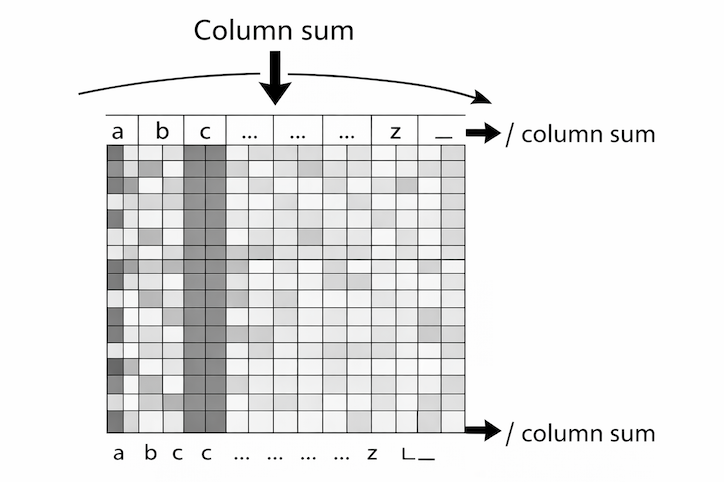

<b>I made this image with chatgpt, it is the best I can show it, but esstentially for each row we divide by it is column sum

In [309]:
P = N.float()
P.shape

torch.Size([27, 27])

<p style="font-size:15px;"> If you don't understand axis in numpy or pytorch you should watch this blog 
  <a href="https://sharpsight.ai/blog/numpy-axes-explained">numpy-axes-explained</a> <br> 

<p style="font-size:15px;">In short: axis 0 would sum each row vertically like over the y-axis, and the result would rows collapse row from 27 into size dimension of 1, with <code>keepdim=True</code> or vanish </p>

In [315]:
p_sum = P.sum(1, keepdim=True) # we sum over axis one 
p_sum.shape

torch.Size([27, 1])